<div style='font-size:14px'>imagine this scenario we have analysed top skills for diff roles individually but what if we wnt to compare the values across each other but they're all on seperate plots, so pyplot module from matplotlib offers a subplots function in order for us to graph everything on one single figure. In cheat sheet look at subplot layouts, with this func we can specify the rows and columns for the no. of axises 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<div style='font-size:14px'>we will strt by creating subplot on basically a 1 by one figure so for this it provide 2 objs fig and ax, this is the stndrd nomenclature for this you can name it whtever u wnt 

In [ ]:
# fig, ax = plt.subplots() #this wil plot only one graph
# fig, ax = plt.subplots(2) #this will plot 2 graphs
fig, ax = plt.subplots(2,2) #this will plot 4 graphs i.e 2*2


<Axes: xlabel='job_title_short'>

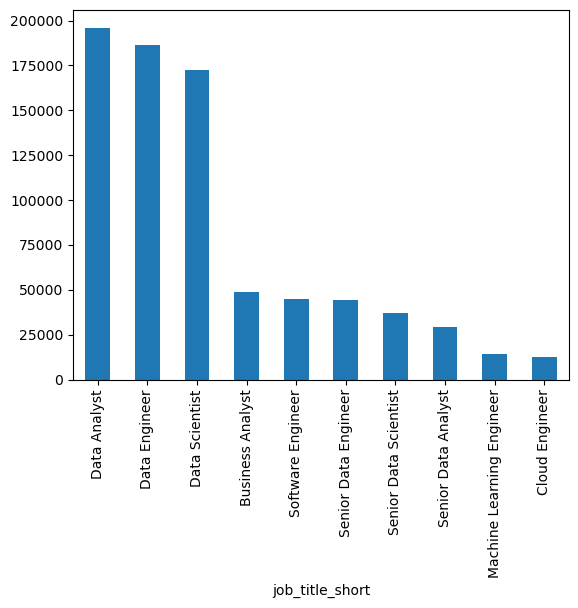

In [13]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar', ax=ax)

<div style='font-size:14px'>now lets get into plotting two graphs

In [ ]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

In [ ]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax)
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax)

<div style='font-size:14px'>this upper code will throw error bcz we need to specify the index of the axe we are using 

<Axes: xlabel='job_schedule_type'>

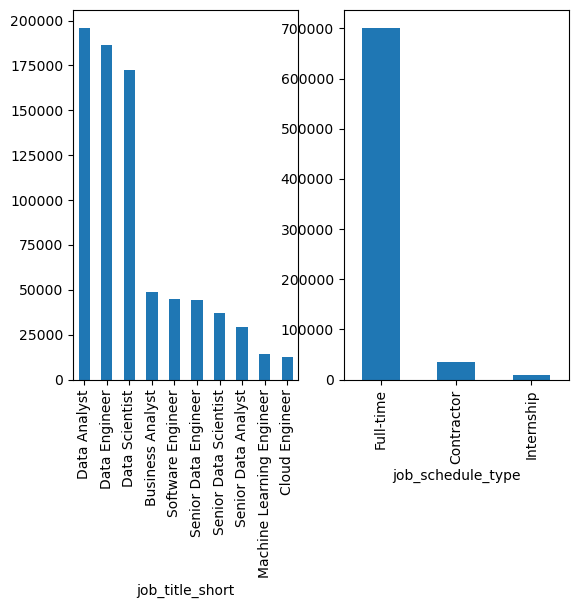

In [18]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

<div style='font-size:14px'>now you can see we have some overlapping this can be fixed by passing a function tight layout and we need to apply this func to the whole figure

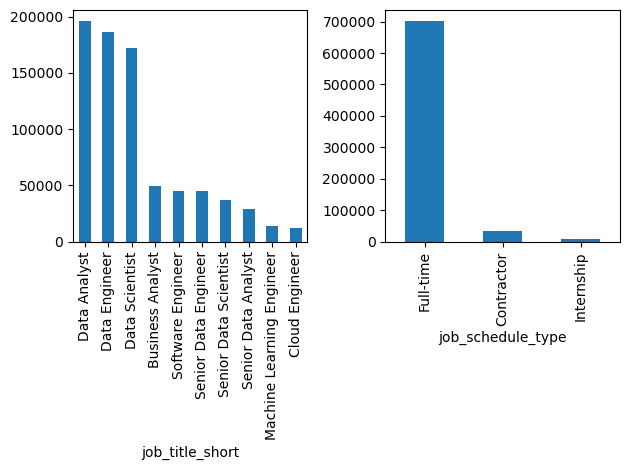

In [19]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

fig.tight_layout()

<div style='font-size:14px'>now till now we were using pandas for plotting, for matplotlib we will write the below provided code

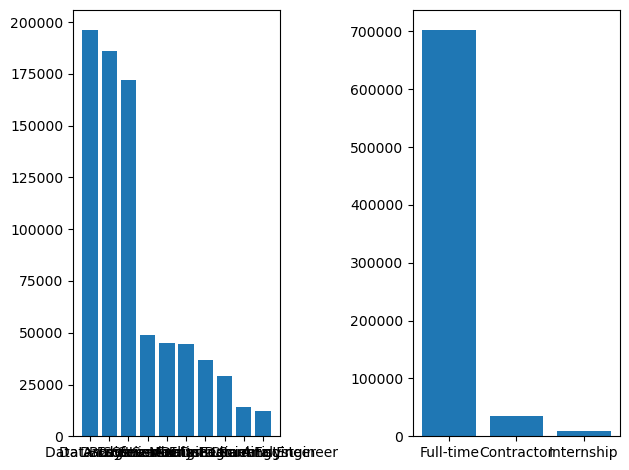

In [22]:
fig, ax = plt.subplots(1,2)

ax[0].bar(df['job_title_short'].value_counts().index, df['job_title_short'].value_counts())
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index, df['job_schedule_type'].value_counts().head(3))

fig.tight_layout()

<div style='font-size:14px'>now our main goal to analyse top skills for data analyst,scientist,engineer altogether

In [30]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [32]:
job_titles=['Data Analyst','Data Scientist','Data Engineer']

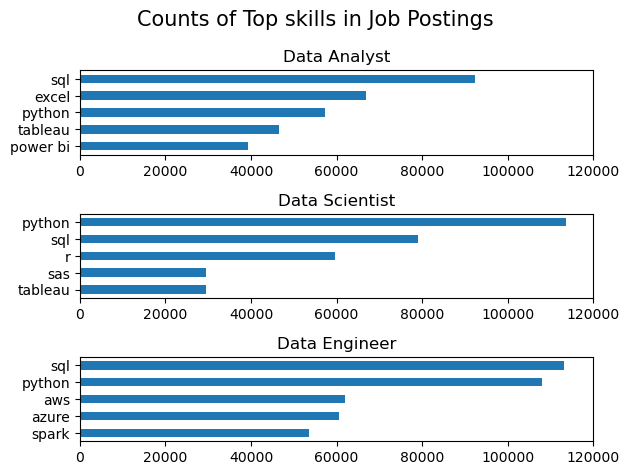

In [50]:
fig, ax = plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)


fig.suptitle('Counts of Top skills in Job Postings',fontsize=15)
fig.tight_layout()